In [1]:
%%capture
!pip uninstall qunum -y
!pip install /Users/matt/qunum

In [50]:
from qunum.numerical import su_n_generate, ad, SUConnection
import torch
A = SUConnection(2)
s = su_n_generate(2, ret_type = 'tqobj')
T= s.clone().to_tensor()[1:]

s[3]*=1j/2
s[1] = (s[1] + 1j*s[2])/2
s[2] = s[1].dag()

s = s.to_tensor()
f = -1j*torch.einsum('abij,cji ->abc', (torch.einsum('aij, bjk->abik',s[1:],s[1:]) - torch.einsum('aij, bjk->baik',s[1:],s[1:])), s[1:])/(s[3] @ s[3]).trace()
fsu2 = -1j*torch.einsum('abij,cji ->abc', torch.einsum('Aij, Bjk-> ABik', T,T) -torch.einsum('Aij, Bjk-> BAik', T,T), T)

torch.einsum('acd, bdc->ab', f, f)

tensor([[-8.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j, -8.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j, -8.+0.j]], dtype=torch.complex128)

In [20]:
import glob, os, copy
maps_loc = O.maps_loc
folder = 'Norm'
D = dict(map(lambda path: (os.path.basename(path).split('.')[0].split('_')[0], path), glob.glob(os.path.join(maps_loc, folder,'*'))))
D
shape = None
if(shape is None):
    shape = dict().fromkeys(D.keys())
else:
    t = dict().fromkeys(D.keys())
    t.update((shape if shape is not None else {})  )
    shape = copy.copy(t)
    del t
shape

{'A': None, 'AaBb': None, 'B': None, 'NIX': None}

In [3]:
import qunum.numerical as qn
from qunum.jupyter_tools.plotting import PlotIt
from qunum.numerical.physics.quantum.heisenberg.bbgky_truncation import BBGKYDecoupling as BBGKY, CMap
import os, torch
import time
import tqdm
def mk_obj(N:int, n:int,**kwargs)->BBGKY:
    print(N,n)
    a = dict(Nsteps= int(4500), u0 = 10_000*1e2, tgt_u0 = 5, debug=False, load_data=False, dp = .1, p0 = torch.tensor(1e10), method = 'gaussrk', adaptive_epsilon=5e-3, dt  = 1e-2, adaptive_time_step=True, r0_Rv = 7.5, p_start_f = .1)
    a.update(kwargs)
    print(a, kwargs)
    return BBGKY(
        N=N, n=n, 
        data_storage_loc=os.path.join('BBGKYSims', f'BBGKY_{N}-{n}'),
        **a
    )
from qunum.numerical.mathematics.algebra import gen_clock
A = gen_clock(3)
A

(tensor([[ 1.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
         [ 0.0000+0.0000j, -0.5000+0.8660j,  0.0000+0.0000j],
         [ 0.0000+0.0000j,  0.0000+0.0000j, -0.5000-0.8660j]],
        dtype=torch.complex128),
 tensor([[0.+0.j, 1.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 1.+0.j],
         [1.+0.j, 0.+0.j, 0.+0.j]], dtype=torch.complex128))

In [4]:
(O.Gamma.conj() * O.Gamma)[O.Norm['AaBb']].sum(-1).shape
print(
    O.Norm['AaBb'].shape
)
for i,j in O.Norm.items():
    print(i, j.shape)


NameError: name 'O' is not defined

In [13]:
O = mk_obj(40,2, Nsteps = 5_000, renorm = False, angular_dependence = 'random_uniform', r0_Rv = 10, tgt_u0 =5 , debug= False, adaptive_epsilon = 1e-3, maps_loc = 'MAPS2', load_maps = False)
for o in tqdm.tqdm(O):
    pass 


20 2
{'Nsteps': 5000, 'u0': 1000000.0, 'tgt_u0': 5, 'debug': False, 'load_data': False, 'dp': 0.1, 'p0': tensor(1.0000e+10), 'method': 'gaussrk', 'adaptive_epsilon': 0.001, 'dt': 0.01, 'adaptive_time_step': True, 'r0_Rv': 10, 'p_start_f': 0.1, 'renorm': False, 'angular_dependence': 'random_uniform', 'maps_loc': 'MAPS2', 'load_maps': False} {'Nsteps': 5000, 'renorm': False, 'angular_dependence': 'random_uniform', 'r0_Rv': 10, 'tgt_u0': 5, 'debug': False, 'adaptive_epsilon': 0.001, 'maps_loc': 'MAPS2', 'load_maps': False}


4999it [01:00, 82.58it/s]


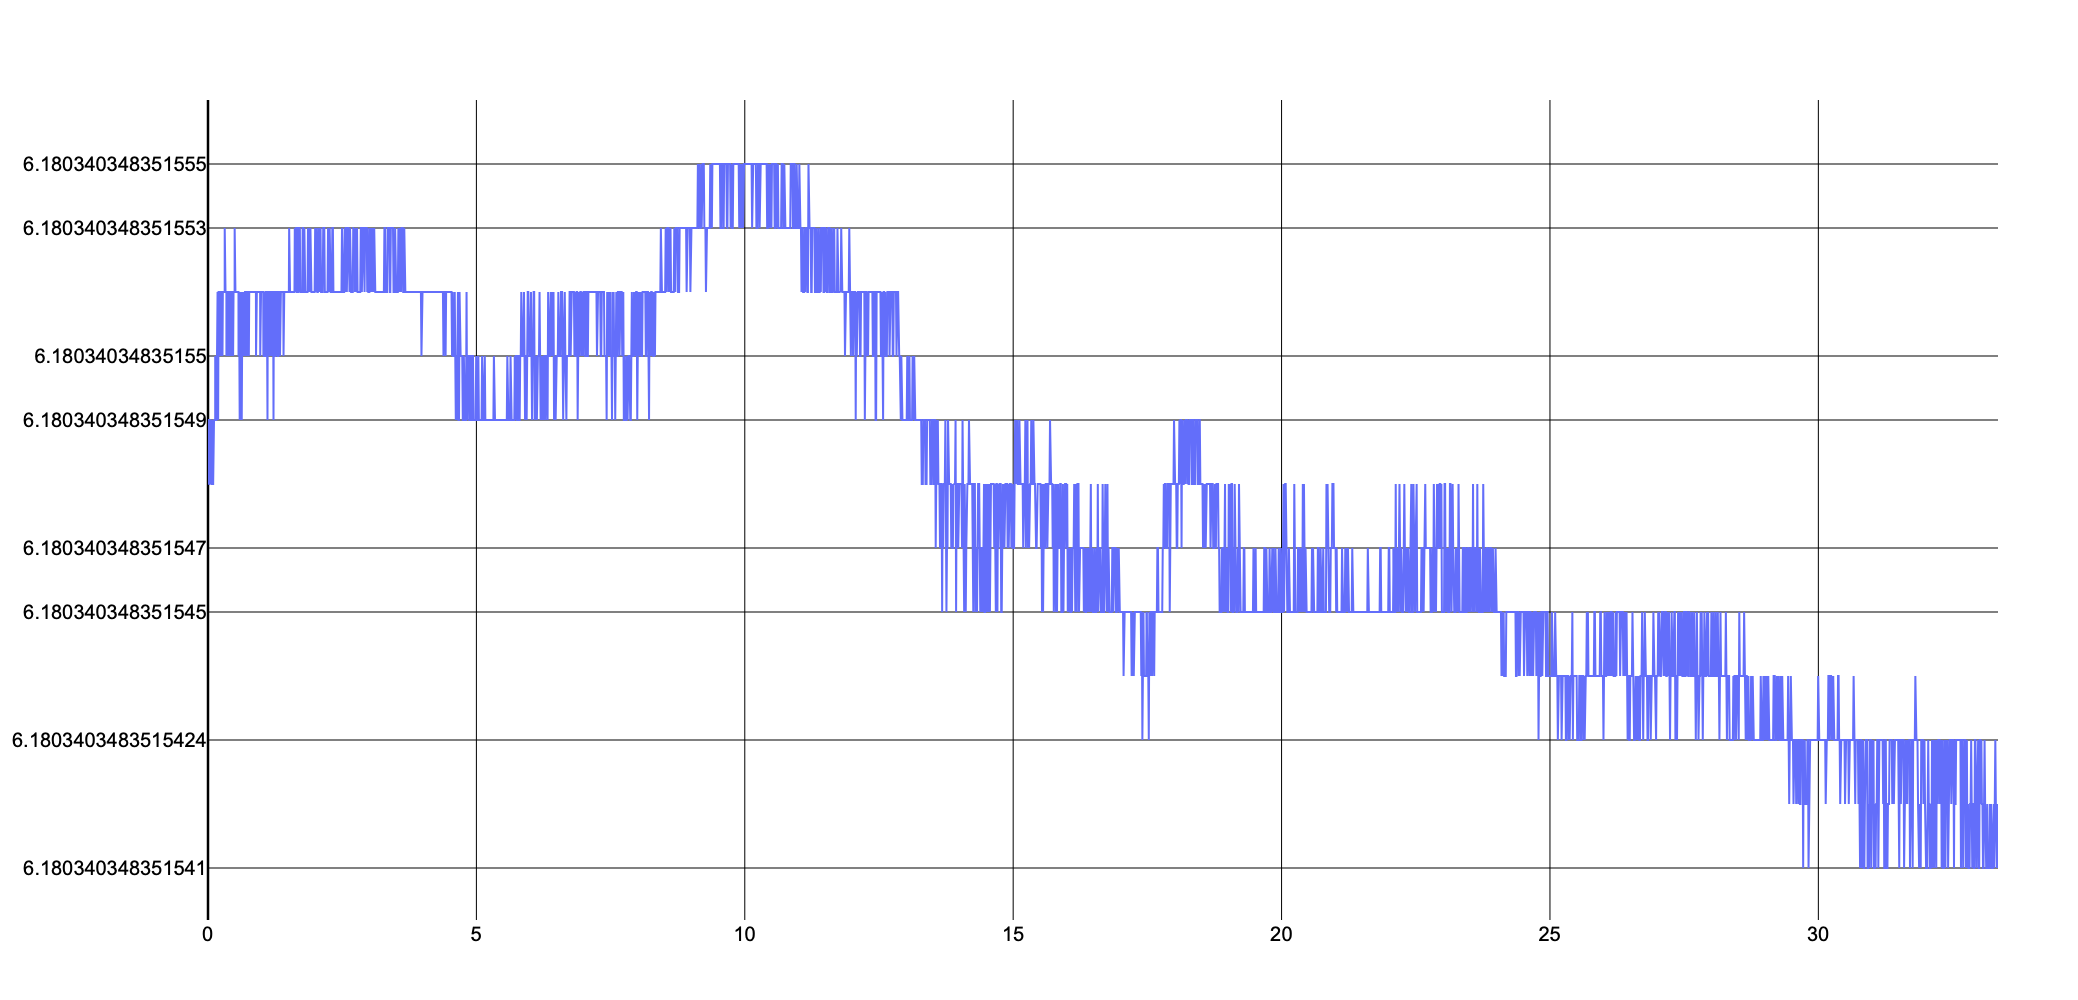

In [14]:
plt.reset()
plt.add_data(x = O.dt.t[:-1], y = O.Phi_t[..., 2].sum(-1).real )
plt.show()

In [8]:
plt = PlotIt()
plt.add_data(x = torch.arange(100), y = O.Phi_t[:,-30,2].real)
plt.show()

IndexError: index -30 is out of bounds for axis 1 with size 10

20 2
{'Nsteps': 5000, 'u0': 1000000.0, 'tgt_u0': 5, 'debug': True, 'load_data': True, 'dp': 0.1, 'p0': tensor(1.0000e+10), 'method': 'gaussrk', 'adaptive_epsilon': 0.005, 'dt': 0.01, 'adaptive_time_step': True, 'r0_Rv': 7.5, 'p_start_f': 0.1, 'renorm': True, 'angular_dependence': 'random_uniform'} {'Nsteps': 5000, 'renorm': True, 'angular_dependence': 'random_uniform', 'load_data': True, 'debug': True}
Loading Tensors


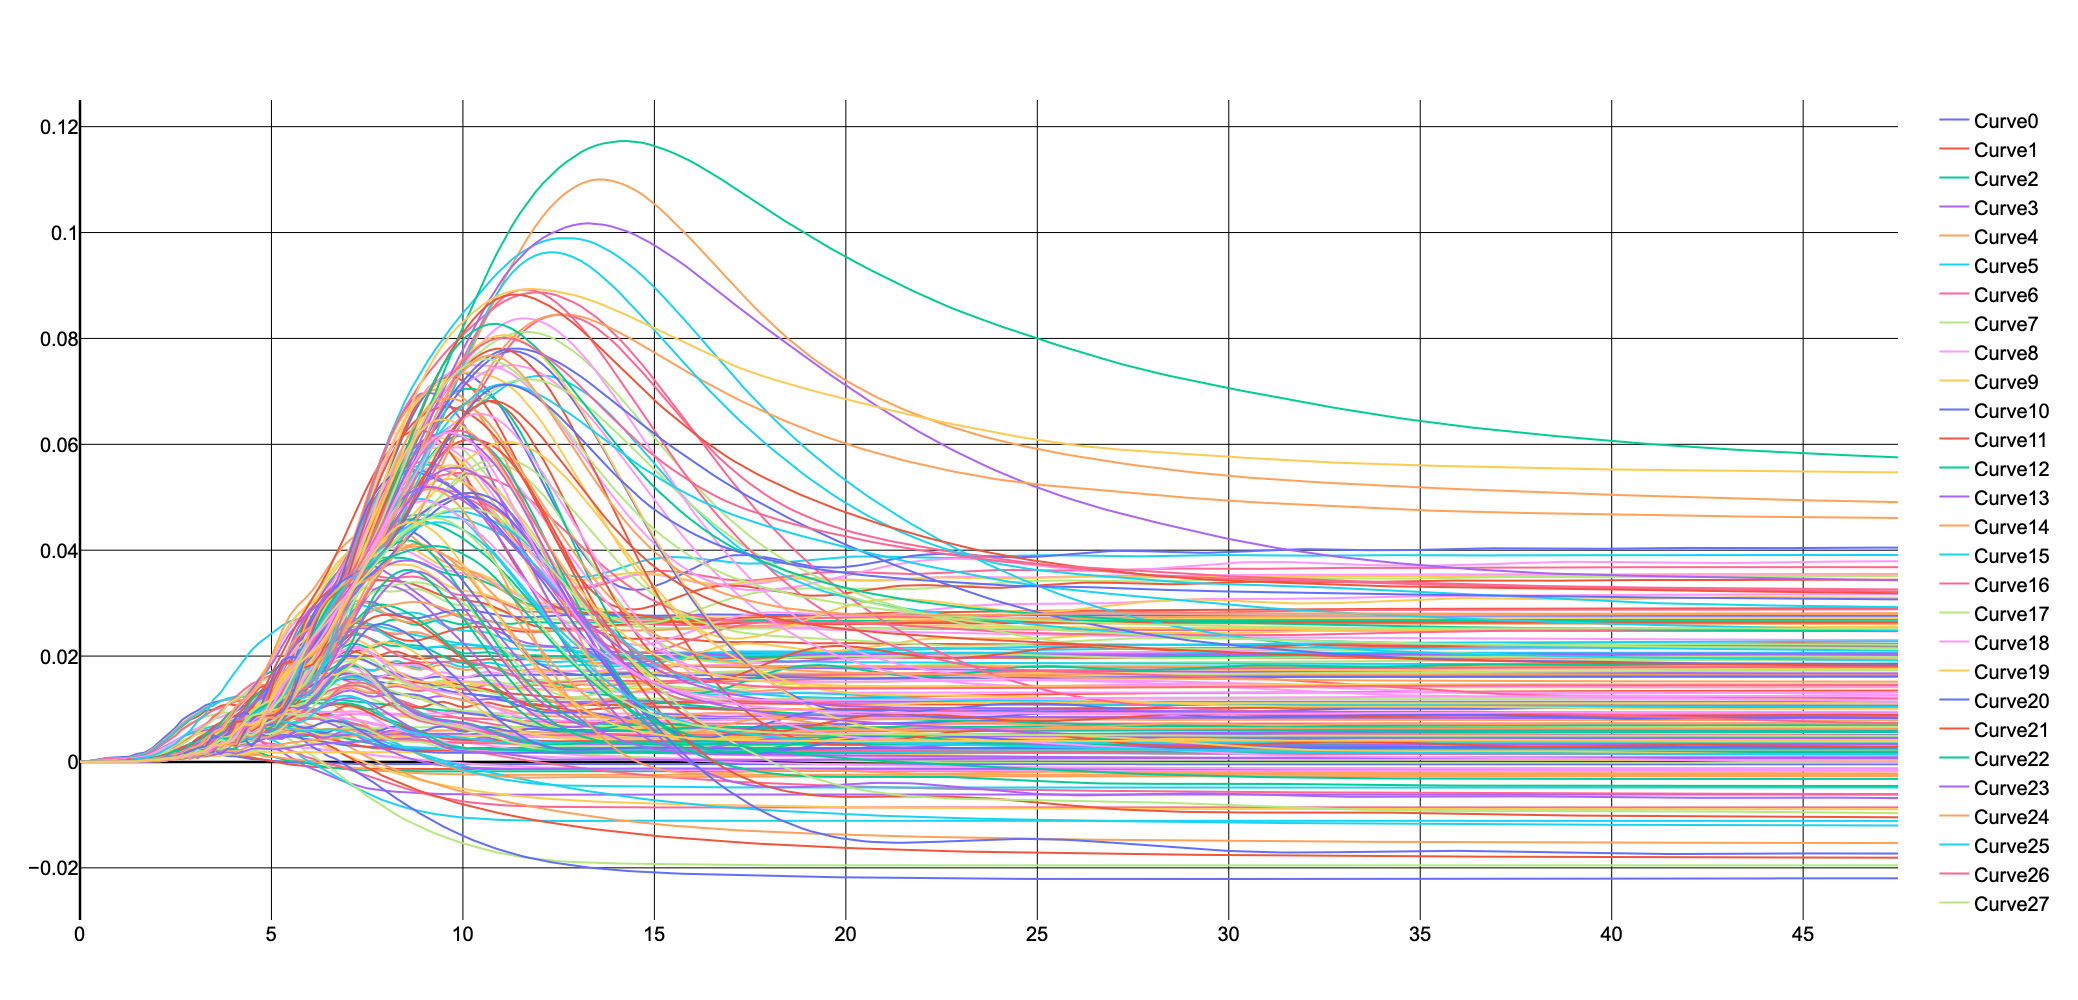

In [32]:
O2 = mk_obj(20,2, Nsteps = 5_000, renorm = True, angular_dependence = 'random_uniform', load_data = True, debug = True)
plt = PlotIt()
t = torch.arange(0, 5_000, step = 20)
S = O2.mutualInformation(t = t)
plt.extend_data(*(dict(x = O.dt.t[t], y = S[:,A] )for A in range(S.shape[1])))
plt.show()

In [33]:
from torch import zeros, diag_embed,exp,pi, arange, tensor, complex128
N = 3

X, Z


(tensor([[0., 1., 0.],
         [0., 0., 1.],
         [1., 0., 0.]]),
 tensor([[ 1.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
         [ 0.0000+0.0000j, -0.5000+0.8660j,  0.0000+0.0000j],
         [ 0.0000+0.0000j,  0.0000+0.0000j, -0.5000-0.8660j]],
        dtype=torch.complex128))

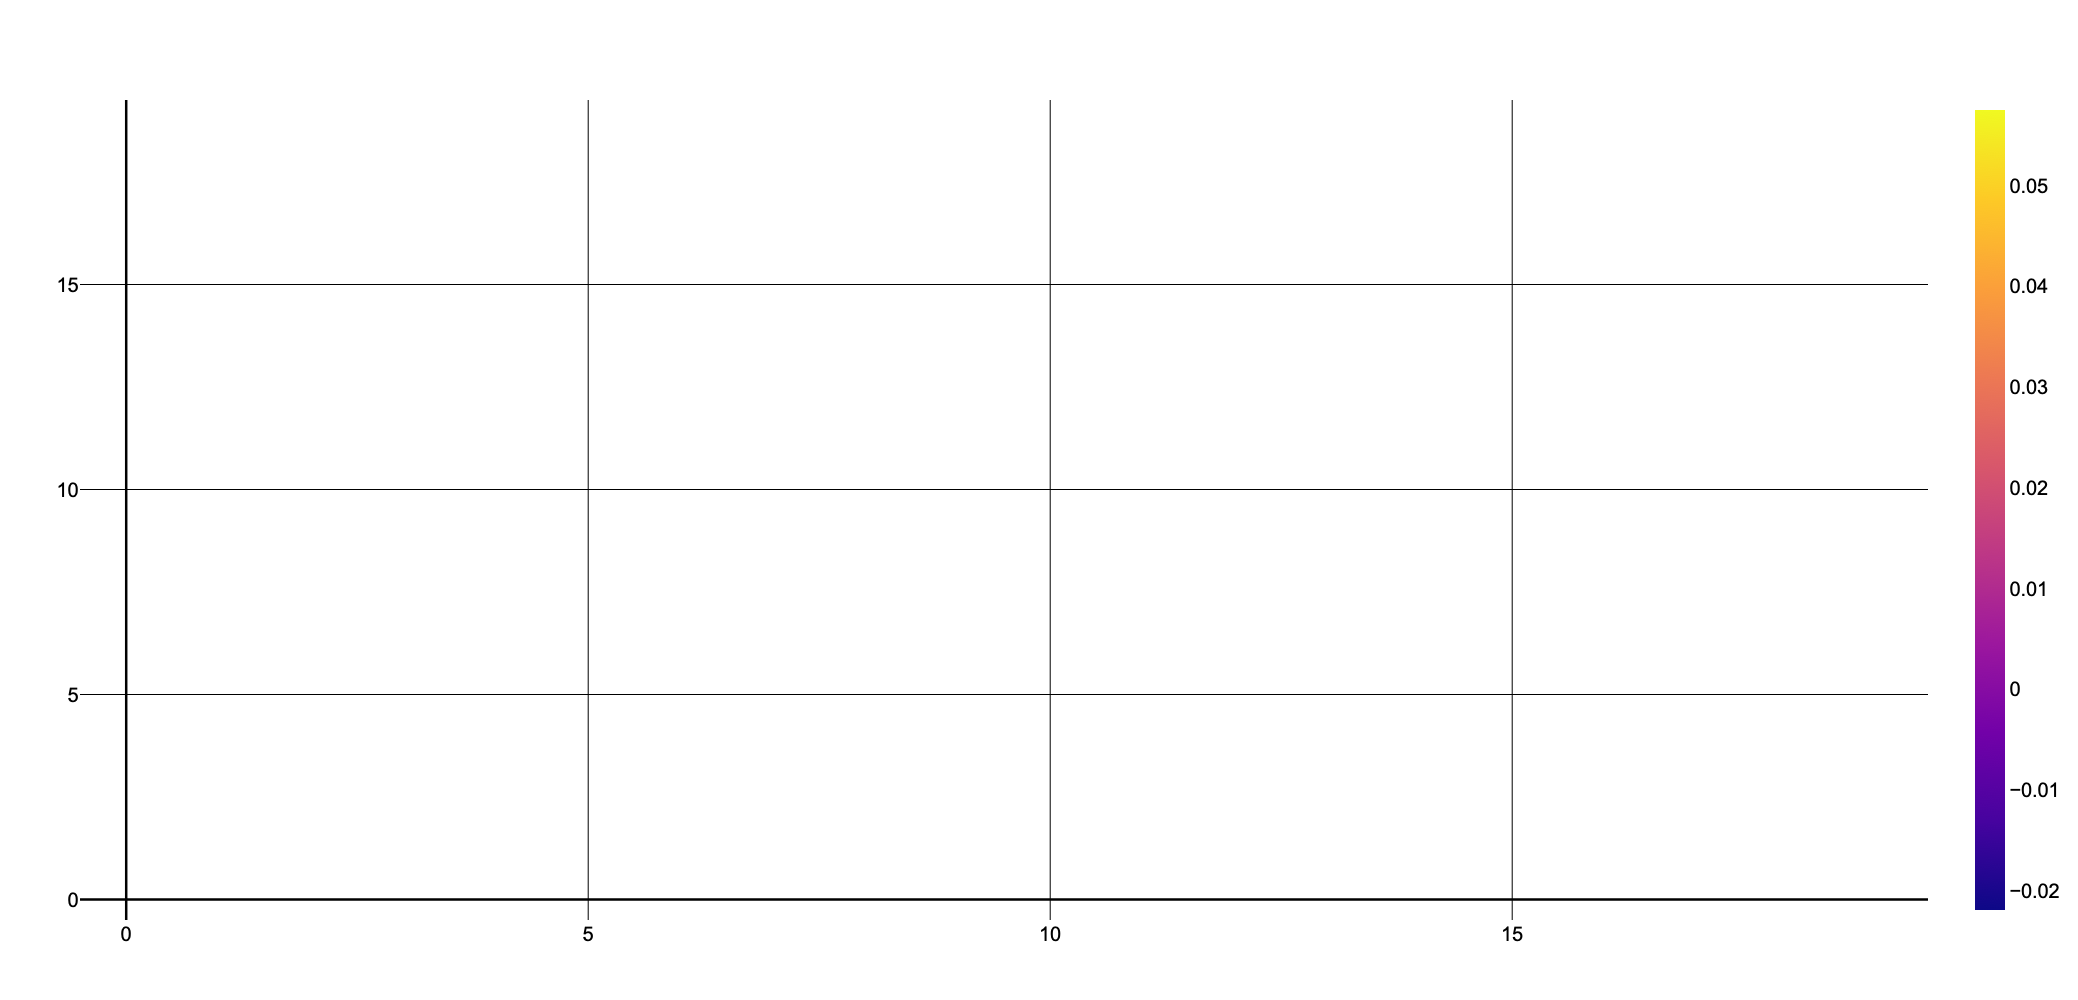

In [34]:
plt.reset()
I = torch.zeros_like(O.Pi)
V, Mp = O.mutualInformation(t =[-1], ret_map=True )
I[Mp['A'].to_torch(), Mp['B'].to_torch()] = V.to(O.Pi.dtype)
I[Mp['B'].to_torch(), Mp['A'].to_torch()] = V.to(O.Pi.dtype)
plt.add_data(type = 'heatmap', x =torch.arange(O.N), y = torch.arange(O.N), z = I)
plt.show()


In [7]:
N = 10
phi = 2*torch.pi*torch.rand(N)
t = torch.arccos(2*torch.rand(N) - 1)
phat = torch.stack([t.sin()*phi.cos(),t.sin()*phi.sin(), t.cos()]).T


torch.Size([10, 3])

KeyboardInterrupt: 

("['multangle.py', 'n=2', 'N=3', 'Nsteps=10', 'I=0']\nBBGKY3-2-4/Data/0_random_uniform\nCreation time 1.13e+00s\ntensor(4.9997)\n",
 '\n0it [00:00, ?it/s]\n9it [00:00, 257.51it/s]\n')

In [ ]:
sax = 1_100 
tav = 1_020.73

In [47]:
import os 
def run_job(n:int = 2, N:int = 100, I:int = 0, Nsteps:int = 5000, sl_time:float = 60, Nproc:int = 5, tot_proc:int = 100):
    procs = dict()
    i = 0 
    pids = set()
    path = os.path.join(os.getcwd(), f'logs_{N}-{n}')
    if not (os.path.exists(path)):
        os.mkdir(path)
    while i < tot_proc:
        for j in range(len(procs), Nproc):
            with open(f'{path}/log{i}.log', 'w') as file:
                temp = subprocess.Popen(['python3', 'multangle.py', 'n=2', 'N=3', 'Nsteps=10', f'I={i}'], stdout=file, stderr=subprocess.PIPE, text=True)
            procs[temp.pid] = temp
            i+=1
        time.sleep(sl_time)
        del_ = set()
        for pid, proc in procs.items():
            if(proc.poll() is not None):
                del_.add(pid)
        for d in del_:
            del procs[d]
    return 

In [48]:
run_job(N=3, Nproc = 2, tot_proc=2, sl_time = 1)

In [21]:
subprocess.PIPE??

Type:        int
String form: -1
Docstring:  
int([x]) -> integer
int(x, base=10) -> integer

Convert a number or string to an integer, or return 0 if no arguments
are given.  If x is a number, return x.__int__().  For floating-point
numbers, this truncates towards zero.

If x is not a number or if base is given, then x must be a string,
bytes, or bytearray instance representing an integer literal in the
given base.  The literal can be preceded by '+' or '-' and be surrounded
by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
Base 0 means to interpret the base from the string as an integer literal.
>>> int('0b100', base=0)
4

In [49]:
{int:'a'}

{int: 'a'}

In [95]:
import time, sys
tot_proc = 110
done_ = set()
t0 = time.time()
Nt = tot_proc/20
print(Nt)
for i in range(tot_proc):
    print('\rTotal Compute Time:{B:.2e}s\tProgress [{A}'.format(B = time.time()-t0, A = ''.join(map(lambda x: ['.','#'][int(len(done_)>=x*Nt-1)], range(1,21)))), end = "]")
    time.sleep(.05)
    done_.add(i)
    if(i>100):
        time.sleep(1)

5.5
Total Compute Time:1.39e+01s	Progress [####################]

In [129]:
import obd, pickle
port = "/dev/cu.usbserial-10"
O = obd.OBD(port, fast = False)

In [52]:
import glob
glob.glob('/Users/matt/bbgky/BBGKY100-2-4/Data/0_random_uniform/*')


['/Users/matt/bbgky/BBGKY100-2-4/Data/0_random_uniform/configs.pkl',
 '/Users/matt/bbgky/BBGKY100-2-4/Data/0_random_uniform/log_4998.txt',
 '/Users/matt/bbgky/BBGKY100-2-4/Data/0_random_uniform/Gamma(t).dat',
 '/Users/matt/bbgky/BBGKY100-2-4/Data/0_random_uniform/times.dat',
 '/Users/matt/bbgky/BBGKY100-2-4/Data/0_random_uniform/Phi(t).dat']

In [60]:
import numpy as np
Phi = np.memmap('/Users/matt/bbgky/BBGKY100-2-4/Data/0_random_uniform/Phi(t).dat', dtype = np.complex128, shape = (5000, 100, 3))

In [62]:
from qunum.jupyter_tools.plotting import PlotIt
plt = PlotIt()

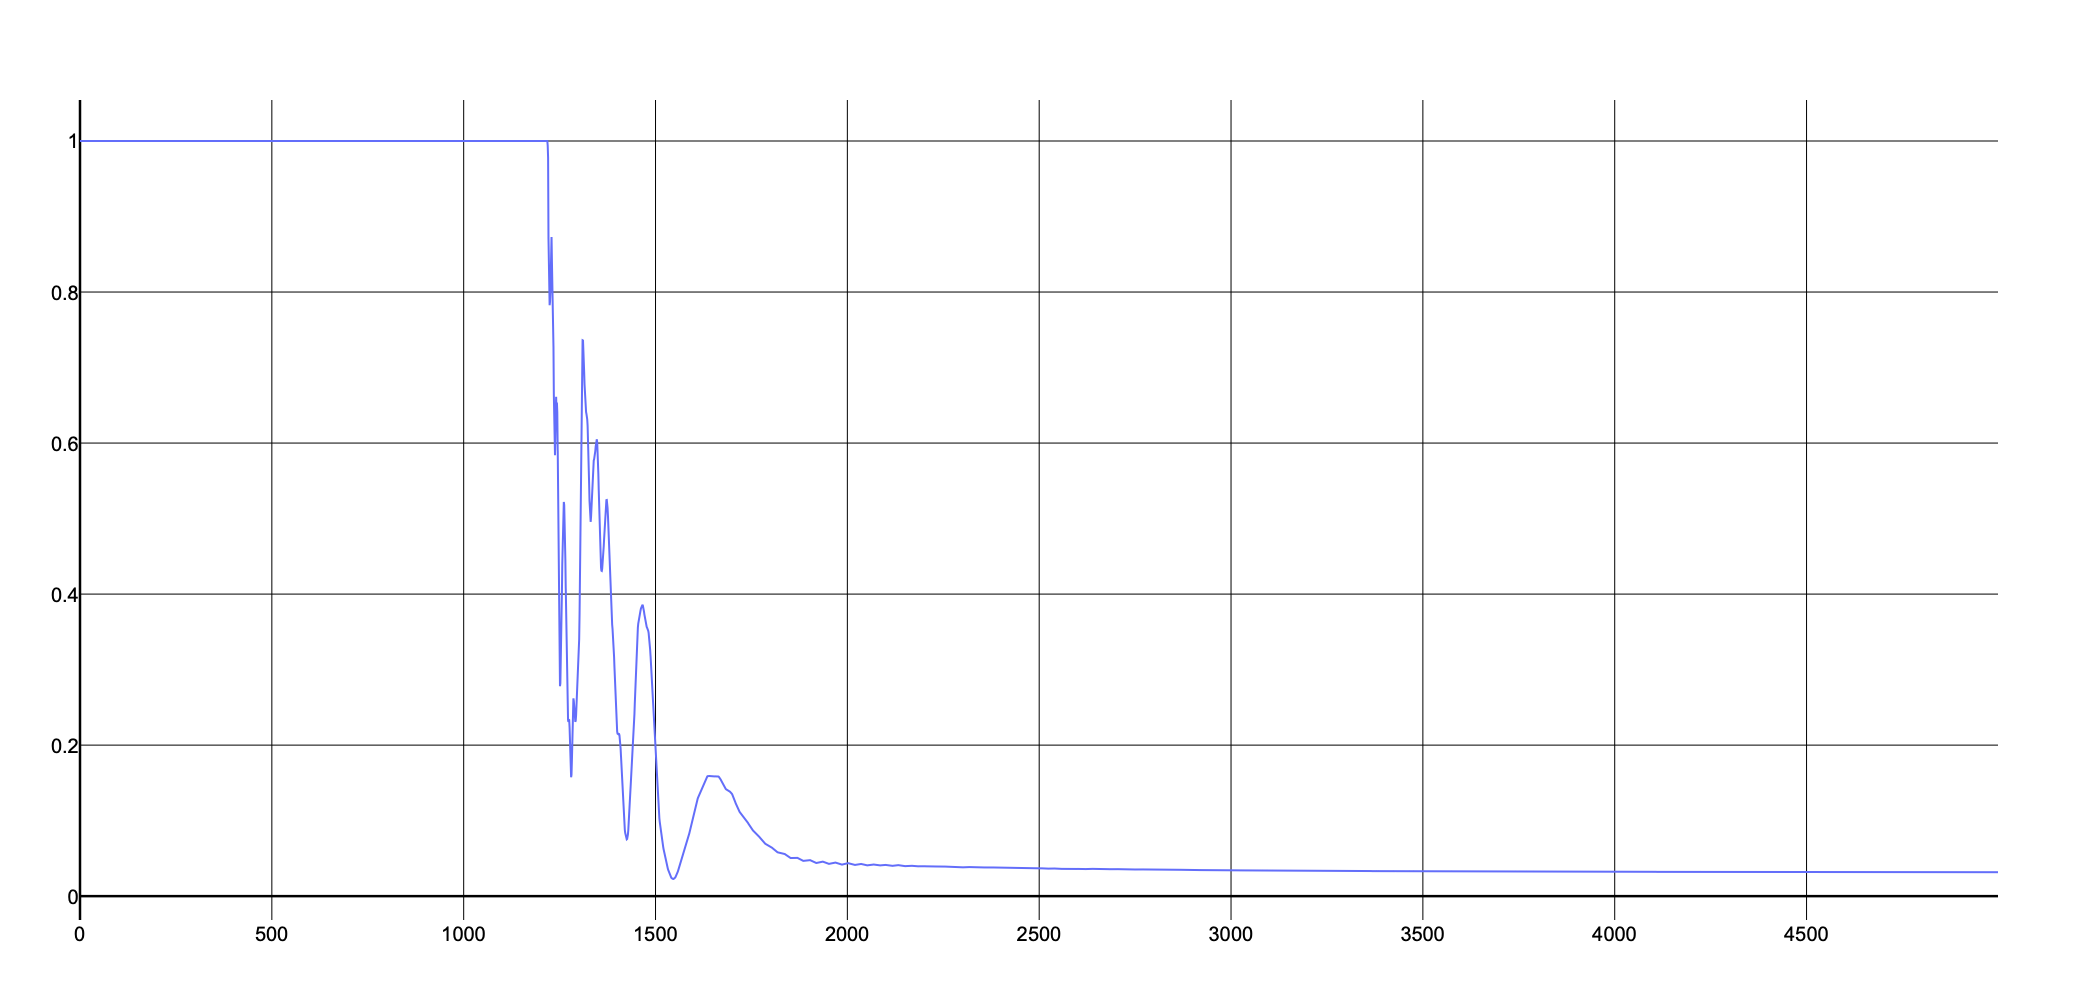

In [76]:
plt.reset()
plt.add_data(x = np.arange(Phi.shape[0]), y = Phi[:,0].real.__pow__(2).sum(-1))
plt.show()

In [ ]:
Phi